In [145]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

## Exercício

Considere $X \sim \mathrm{Binomial}(n,p)$.

1. Implemente a simulação de $X$ pelo método ingênuo, escrevendo $X$ como soma de $n$ variáveis aleatórias independentes com distribuição $\mathrm{Bernoulli}(p)$.

In [67]:
p = 0.5
X = []
N = 1000
n = 100
for i in range(N):
    U = np.random.uniform(size= n)
    X.append(np.sum(U < p))

2. Implemente o método recursivo visto em sala:

   * Gere $U \sim U(0,1)$.

   * Inicialize $i=0$, $p_i=(1-p)^n$ e $F=p_i$.

   * Enquanto $U>F$, faça

     $$
     p_{i+1}=
     \frac{n-i}{i+1}
     \frac{p}{1-p}
     p_i,
     $$

     e atualize $i \leftarrow i+1$ e $F \leftarrow F+p_i$.

   * Retorne $X=i$.

In [69]:
# Recursivo
X2 = []
for i in range(N):
    U = np.random.uniform()
    i = 0
    pi = (1-p)**n
    F = pi
    while U > F:
        pi = (n-i) * p * pi/((i+1) * (1-p))
        i += 1
        F += pi
    X2.append(i)

In [92]:
binomial = np.random.binomial(n, p,size = N)

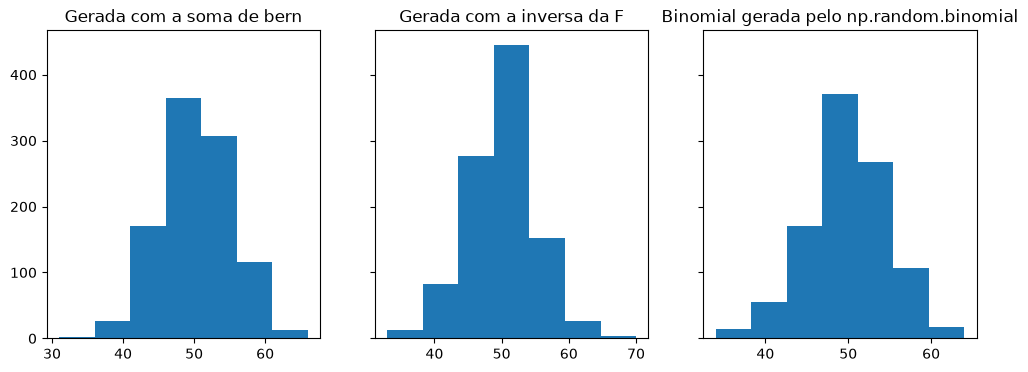

In [93]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax[0].hist(X, bins = 7)
ax[0].set_title('Gerada com a soma de bern')

ax[1].hist(X2, bins = 7)
ax[1].set_title('Gerada com a inversa da F')


ax[2].hist(binomial, bins = 7)
ax[2].set_title('Binomial gerada pelo np.random.binomial')

plt.show()

3. Use a função `np.linspace` para reproduzir os passos anteriores para diferentes valores de $p$, compare o tempo de execução dos dois métodos. Para cada valor de $p$, execute cada método 100 vezes e calcule a média dos tempos. Utilize `time.time()` para medir o tempo de execução de cada método. 

In [148]:
tempo1 = []
ps = np.linspace(start = 0, stop= 0.99, num = 500)
for p in tqdm(ps):
    comeco = time.time()
    for i in range(N):
        U = np.random.uniform(size= n)
        X.append(np.sum(U < p))
    tempo1.append(time.time() - comeco)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:04<00:00, 100.78it/s]


In [149]:
tempo2 = []
for p in tqdm(ps):
    comeco = time.time()
    X2 = []
    for i in range(N):
        U = np.random.uniform()
        i = 0
        pi = (1-p)**n
        F = pi
        while U > F:
            pi = (n-i) * p * pi/((i+1) * (1-p))
            i += 1
            F += pi
        X2.append(i)
    tempo2.append(time.time() - comeco)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:10<00:00, 45.60it/s]


In [154]:
print(f'Tempo médio para ingênua: {np.mean(tempo1)}')
print(f'Tempo médio para inversa da F: {np.mean(tempo2)}')

Tempo médio para ingênua: 0.009817737579345703
Tempo médio para inversa da F: 0.021817463397979735


4.. Apresente os resultados em uma tabela ou gráfico e comente como o tempo de execução dos métodos varia com $p$.

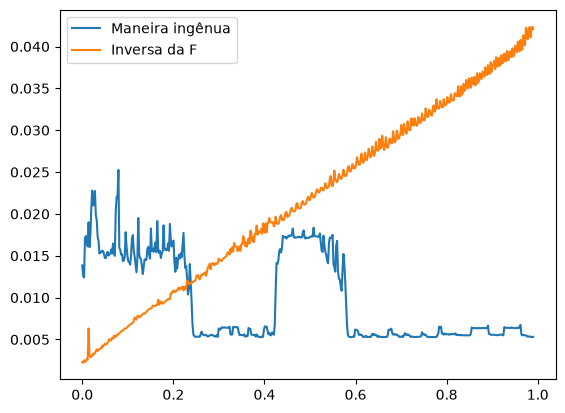

In [152]:
plt.plot(ps, tempo1)
plt.plot(ps, tempo2)
plt.legend(['Maneira ingênua', 'Inversa da F'])
plt.show()

## Como o p cresce, a inversa acaba inteirando muitas vezes para encontrar os valores da variável altos